# **INSTALL PACKAGES**

In [ ]:
!pip install geopandas

# **PRE-PROCESSING DATA**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel('/content/data ads.xlsx')
df

,alamat,latitude1,longitude1,bod,latitude2,longitude2,cod
0,Jl. Kelapa Dua Srengseng Sawah,-6.343319,106.838232,4.8,-6.343319,106.838232,40.75
1,Komp Kopassus Cijantung,-6.321946,106.840791,5.8,-6.321946,106.840791,49.03
2,Kampung Gedong Intake PAM,-6.298630,106.850318,9.1,-6.298630,106.850318,77.70
3,Jl. Kalibata,-6.258176,106.860457,9.2,-6.258176,106.860457,78.39
4,Kampung Melayu Dalam,-6.228147,106.864621,6.6,-6.228147,106.864621,50.76
5,Sebelum Pintu Air Manggarai,-6.212654,106.857741,6.1,-6.212654,106.857741,46.62
6,Jl. Halimun,-6.204944,106.833889,7.4,-6.204944,106.833889,57.32
7,Jembatan Jalan Tambak,-6.201389,106.850944,9.0,-6.201389,106.850944,71.14
8,Jl. KH Mas Mansyur Karet Tengsin,-6.200984,106.815148,6.5,-6.200984,106.815148,49.72
9,Gudang PLN,-6.198190,106.809960,6.3,-6.198190,106.809960,48.34


In [ ]:
latitude1 = df['latitude1'].values
longitude1 = df['longitude1'].values
latitude2 = df['latitude2'].values
longitude2 = df['longitude2'].values

# Create the cor_u and cor_v array
cor_u = np.column_stack((latitude1, longitude1))
cor_v = np.column_stack((latitude2, longitude2))

loc_u = np.array(df['alamat'])
data_u = np.array(df['bod'])
loc_v = np.array(df['alamat'])
data_v = np.array(df['cod'])

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_u = StandardScaler()
data_u = data_u.reshape(-1,1)
data_u = scaler_u.fit_transform(data_u)
scaler_v = StandardScaler()
data_v = data_v.reshape(-1,1)
data_v = scaler_v.fit_transform(data_v)

In [ ]:
# Create DataFrame for dataset u
prim_u = pd.DataFrame(data_u, columns=['Value'], index=loc_u)

# Create DataFrame for dataset v
sec_v = pd.DataFrame(data_v, columns=['Value'], index=loc_v)

# Combine datasets
data_uv = pd.concat([prim_u, sec_v], keys=['u', 'v'])
data_uv

Value
u Jl. Kelapa Dua Srengseng Sawah   -1.350710
  Komp Kopassus Cijantung          -0.770651
  Kampung Gedong Intake PAM         1.143546
  Jl. Kalibata                      1.201552
  Kampung Melayu Dalam             -0.306603
  Sebelum Pintu Air Manggarai      -0.596633
  Jl. Halimun                       0.157445
  Jembatan Jalan Tambak             1.085540
  Jl. KH Mas Mansyur Karet Tengsin -0.364609
  Gudang PLN                       -0.480621
  Jl. Kwitang Dalam Gunung Agung   -0.654639
  Jl. Inspeksi Banjir Istiqlal     -1.350710
  Jl. Gajah Mada Tangki             0.157445
  Jl. Gunung Sahari Depan WTC       2.129647
v Jl. Kelapa Dua Srengseng Sawah   -1.070921
  Komp Kopassus Cijantung          -0.516051
  Kampung Gedong Intake PAM         1.405222
  Jl. Kalibata                      1.451461
  Kampung Melayu Dalam             -0.400118
  Sebelum Pintu Air Manggarai      -0.677553
  Jl. Halimun                       0.039490
  Jembatan Jalan Tambak             0.965615
  Jl. KH Mas Mansyur Karet Tengsin -0.469811
  Gudang PLN                       -0.562290
  Jl. Kwitang Dalam Gunung Agung   -0.747247
  Jl. Inspeksi Banjir Istiqlal     -1.418050
  Jl. Gajah Mada Tangki             0.039490
  Jl. Gunung Sahari Depan WTC       1.960763

# **COKRIGING**

## **MATRIKS hij**

In [ ]:
import pandas as pd
from scipy.spatial import distance_matrix

# Menampilkan semua kolom agar tidak terpotong
pd.set_option('display.max_columns', None)

# (Opsional) Menampilkan semua baris juga
pd.set_option('display.max_rows', None)

# (Opsional) Menampilkan semua lebar kolom
pd.set_option('display.max_colwidth', None)

# Create DataFrame for dataset u
df_u = pd.DataFrame(cor_u, columns=['Latitude', 'Longitude'], index=loc_u)

# Create DataFrame for dataset v
df_v = pd.DataFrame(cor_v, columns=['Latitude', 'Longitude'], index=loc_v)

# Combine datasets
df_combined = pd.concat([df_u, df_v], keys=['u', 'v'])

# Calculate Euclidean distance matrix
mat_hij = pd.DataFrame(distance_matrix(df_combined.values, df_combined.values), index=df_combined.index, columns=df_combined.index)

print("\nEuclidean Distance Matrix:")
mat_hij


Euclidean Distance Matrix:


u  \
                                   Jl. Kelapa Dua Srengseng Sawah   
u Jl. Kelapa Dua Srengseng Sawah                         0.000000   
  Komp Kopassus Cijantung                                0.021526   
  Kampung Gedong Intake PAM                              0.046294   
  Jl. Kalibata                                           0.087996   
  Kampung Melayu Dalam                                   0.118156   
  Sebelum Pintu Air Manggarai                            0.132113   
  Jl. Halimun                                            0.138443   
  Jembatan Jalan Tambak                                  0.142498   
  Jl. KH Mas Mansyur Karet Tengsin                       0.144195   
  Gudang PLN                                             0.147857   
  Jl. Kwitang Dalam Gunung Agung                         0.160949   
  Jl. Inspeksi Banjir Istiqlal                           0.172296   
  Jl. Gajah Mada Tangki                                  0.184359   
  Jl. Gunung Sahari Depan WTC                            0.208815   
v Jl. Kelapa Dua Srengseng Sawah                         0.000000   
  Komp Kopassus Cijantung                                0.021526   
  Kampung Gedong Intake PAM                              0.046294   
  Jl. Kalibata                                           0.087996   
  Kampung Melayu Dalam                                   0.118156   
  Sebelum Pintu Air Manggarai                            0.132113   
  Jl. Halimun                                            0.138443   
  Jembatan Jalan Tambak                                  0.142498   
  Jl. KH Mas Mansyur Karet Tengsin                       0.144195   
  Gudang PLN                                             0.147857   
  Jl. Kwitang Dalam Gunung Agung                         0.160949   
  Jl. Inspeksi Banjir Istiqlal                           0.172296   
  Jl. Gajah Mada Tangki                                  0.184359   
  Jl. Gunung Sahari Depan WTC                            0.208815   

                                                            \
                                   Komp Kopassus Cijantung   
u Jl. Kelapa Dua Srengseng Sawah                  0.021526   
  Komp Kopassus Cijantung                         0.000000   
  Kampung Gedong Intake PAM                       0.025187   
  Jl. Kalibata                                    0.066734   
  Kampung Melayu Dalam                            0.096779   
  Sebelum Pintu Air Manggarai                     0.110599   
  Jl. Halimun                                     0.117205   
  Jembatan Jalan Tambak                           0.120984   
  Jl. KH Mas Mansyur Karet Tengsin                0.123650   
  Gudang PLN                                      0.127539   
  Jl. Kwitang Dalam Gunung Agung                  0.139626   
  Jl. Inspeksi Banjir Istiqlal                    0.151114   
  Jl. Gajah Mada Tangki                           0.163436   
  Jl. Gunung Sahari Depan WTC                     0.187563   
v Jl. Kelapa Dua Srengseng Sawah                  0.021526   
  Komp Kopassus Cijantung                         0.000000   
  Kampung Gedong Intake PAM                       0.025187   
  Jl. Kalibata                                    0.066734   
  Kampung Melayu Dalam                            0.096779   
  Sebelum Pintu Air Manggarai                     0.110599   
  Jl. Halimun                                     0.117205   
  Jembatan Jalan Tambak                           0.120984   
  Jl. KH Mas Mansyur Karet Tengsin                0.123650   
  Gudang PLN                                      0.127539   
  Jl. Kwitang Dalam Gunung Agung                  0.139626   
  Jl. Inspeksi Banjir Istiqlal                    0.151114   
  Jl. Gajah Mada Tangki                           0.163436   
  Jl. Gunung Sahari Depan WTC                     0.187563   

                                                                           \
                                   Kampung Gedong Intak

## **SEMIVARIOGRAM EKSPERIMENTAL**

In [ ]:
mat_hij_u = mat_hij.loc['u','u']
mat_hij_u

,Jl. Kelapa Dua Srengseng Sawah,Komp Kopassus Cijantung,Kampung Gedong Intake PAM,Jl. Kalibata,Kampung Melayu Dalam,Sebelum Pintu Air Manggarai,Jl. Halimun,Jembatan Jalan Tambak,Jl. KH Mas Mansyur Karet Tengsin,Gudang PLN,Jl. Kwitang Dalam Gunung Agung,Jl. Inspeksi Banjir Istiqlal,Jl. Gajah Mada Tangki,Jl. Gunung Sahari Depan WTC
Jl. Kelapa Dua Srengseng Sawah,0.000000,0.021526,0.046294,0.087996,0.118156,0.132113,0.138443,0.142498,0.144195,0.147857,0.160949,0.172296,0.184359,0.208815
Komp Kopassus Cijantung,0.021526,0.000000,0.025187,0.066734,0.096779,0.110599,0.117205,0.120984,0.123650,0.127539,0.139626,0.151114,0.163436,0.187563
Kampung Gedong Intake PAM,0.046294,0.025187,0.000000,0.041705,0.071920,0.086296,0.095116,0.097243,0.103787,0.108245,0.117032,0.129027,0.142145,0.165090
Jl. Kalibata,0.087996,0.066734,0.041705,0.000000,0.030316,0.045603,0.059494,0.057578,0.072965,0.078411,0.079392,0.092152,0.106573,0.126905
Kampung Melayu Dalam,0.118156,0.096779,0.071920,0.030316,0.000000,0.016952,0.038508,0.030051,0.056439,0.062332,0.053539,0.066655,0.081990,0.099216
Sebelum Pintu Air Manggarai,0.132113,0.110599,0.086296,0.045603,0.016952,0.000000,0.025067,0.013157,0.044163,0.049922,0.036788,0.049893,0.065348,0.082326
Jl. Halimun,0.138443,0.117205,0.095116,0.059494,0.038508,0.025067,0.000000,0.017422,0.019155,0.024864,0.022761,0.033952,0.047357,0.070372
Jembatan Jalan Tambak,0.142498,0.120984,0.097243,0.057578,0.030051,0.013157,0.017422,0.000000,0.035798,0.041109,0.023669,0.036757,0.052257,0.069542
Jl. KH Mas Mansyur Karet Tengsin,0.144195,0.123650,0.103787,0.072965,0.056439,0.044163,0.019155,0.035798,0.000000,0.005893,0.028585,0.033237,0.041218,0.068364
Gudang PLN,0.147857,0.127539,0.108245,0.078411,0.062332,0.049922,0.024864,0.041109,0.005893,0.000000,0.031193,0.033565,0.039311,0.067138


In [ ]:
mat_hij_v = mat_hij.loc['v','v']
mat_hij_v

,Jl. Kelapa Dua Srengseng Sawah,Komp Kopassus Cijantung,Kampung Gedong Intake PAM,Jl. Kalibata,Kampung Melayu Dalam,Sebelum Pintu Air Manggarai,Jl. Halimun,Jembatan Jalan Tambak,Jl. KH Mas Mansyur Karet Tengsin,Gudang PLN,Jl. Kwitang Dalam Gunung Agung,Jl. Inspeksi Banjir Istiqlal,Jl. Gajah Mada Tangki,Jl. Gunung Sahari Depan WTC
Jl. Kelapa Dua Srengseng Sawah,0.000000,0.021526,0.046294,0.087996,0.118156,0.132113,0.138443,0.142498,0.144195,0.147857,0.160949,0.172296,0.184359,0.208815
Komp Kopassus Cijantung,0.021526,0.000000,0.025187,0.066734,0.096779,0.110599,0.117205,0.120984,0.123650,0.127539,0.139626,0.151114,0.163436,0.187563
Kampung Gedong Intake PAM,0.046294,0.025187,0.000000,0.041705,0.071920,0.086296,0.095116,0.097243,0.103787,0.108245,0.117032,0.129027,0.142145,0.165090
Jl. Kalibata,0.087996,0.066734,0.041705,0.000000,0.030316,0.045603,0.059494,0.057578,0.072965,0.078411,0.079392,0.092152,0.106573,0.126905
Kampung Melayu Dalam,0.118156,0.096779,0.071920,0.030316,0.000000,0.016952,0.038508,0.030051,0.056439,0.062332,0.053539,0.066655,0.081990,0.099216
Sebelum Pintu Air Manggarai,0.132113,0.110599,0.086296,0.045603,0.016952,0.000000,0.025067,0.013157,0.044163,0.049922,0.036788,0.049893,0.065348,0.082326
Jl. Halimun,0.138443,0.117205,0.095116,0.059494,0.038508,0.025067,0.000000,0.017422,0.019155,0.024864,0.022761,0.033952,0.047357,0.070372
Jembatan Jalan Tambak,0.142498,0.120984,0.097243,0.057578,0.030051,0.013157,0.017422,0.000000,0.035798,0.041109,0.023669,0.036757,0.052257,0.069542
Jl. KH Mas Mansyur Karet Tengsin,0.144195,0.123650,0.103787,0.072965,0.056439,0.044163,0.019155,0.035798,0.000000,0.005893,0.028585,0.033237,0.041218,0.068364
Gudang PLN,0.147857,0.127539,0.108245,0.078411,0.062332,0.049922,0.024864,0.041109,0.005893,0.000000,0.031193,0.033565,0.039311,0.067138


In [ ]:
mat_hij_uv = mat_hij.loc['u','v']
mat_hij_uv

,Jl. Kelapa Dua Srengseng Sawah,Komp Kopassus Cijantung,Kampung Gedong Intake PAM,Jl. Kalibata,Kampung Melayu Dalam,Sebelum Pintu Air Manggarai,Jl. Halimun,Jembatan Jalan Tambak,Jl. KH Mas Mansyur Karet Tengsin,Gudang PLN,Jl. Kwitang Dalam Gunung Agung,Jl. Inspeksi Banjir Istiqlal,Jl. Gajah Mada Tangki,Jl. Gunung Sahari Depan WTC
Jl. Kelapa Dua Srengseng Sawah,0.000000,0.021526,0.046294,0.087996,0.118156,0.132113,0.138443,0.142498,0.144195,0.147857,0.160949,0.172296,0.184359,0.208815
Komp Kopassus Cijantung,0.021526,0.000000,0.025187,0.066734,0.096779,0.110599,0.117205,0.120984,0.123650,0.127539,0.139626,0.151114,0.163436,0.187563
Kampung Gedong Intake PAM,0.046294,0.025187,0.000000,0.041705,0.071920,0.086296,0.095116,0.097243,0.103787,0.108245,0.117032,0.129027,0.142145,0.165090
Jl. Kalibata,0.087996,0.066734,0.041705,0.000000,0.030316,0.045603,0.059494,0.057578,0.072965,0.078411,0.079392,0.092152,0.106573,0.126905
Kampung Melayu Dalam,0.118156,0.096779,0.071920,0.030316,0.000000,0.016952,0.038508,0.030051,0.056439,0.062332,0.053539,0.066655,0.081990,0.099216
Sebelum Pintu Air Manggarai,0.132113,0.110599,0.086296,0.045603,0.016952,0.000000,0.025067,0.013157,0.044163,0.049922,0.036788,0.049893,0.065348,0.082326
Jl. Halimun,0.138443,0.117205,0.095116,0.059494,0.038508,0.025067,0.000000,0.017422,0.019155,0.024864,0.022761,0.033952,0.047357,0.070372
Jembatan Jalan Tambak,0.142498,0.120984,0.097243,0.057578,0.030051,0.013157,0.017422,0.000000,0.035798,0.041109,0.023669,0.036757,0.052257,0.069542
Jl. KH Mas Mansyur Karet Tengsin,0.144195,0.123650,0.103787,0.072965,0.056439,0.044163,0.019155,0.035798,0.000000,0.005893,0.028585,0.033237,0.041218,0.068364
Gudang PLN,0.147857,0.127539,0.108245,0.078411,0.062332,0.049922,0.024864,0.041109,0.005893,0.000000,0.031193,0.033565,0.039311,0.067138


In [ ]:
mat_hij

u  \
                                   Jl. Kelapa Dua Srengseng Sawah   
u Jl. Kelapa Dua Srengseng Sawah                         0.000000   
  Komp Kopassus Cijantung                                0.021526   
  Kampung Gedong Intake PAM                              0.046294   
  Jl. Kalibata                                           0.087996   
  Kampung Melayu Dalam                                   0.118156   
  Sebelum Pintu Air Manggarai                            0.132113   
  Jl. Halimun                                            0.138443   
  Jembatan Jalan Tambak                                  0.142498   
  Jl. KH Mas Mansyur Karet Tengsin                       0.144195   
  Gudang PLN                                             0.147857   
  Jl. Kwitang Dalam Gunung Agung                         0.160949   
  Jl. Inspeksi Banjir Istiqlal                           0.172296   
  Jl. Gajah Mada Tangki                                  0.184359   
  Jl. Gunung Sahari Depan WTC                            0.208815   
v Jl. Kelapa Dua Srengseng Sawah                         0.000000   
  Komp Kopassus Cijantung                                0.021526   
  Kampung Gedong Intake PAM                              0.046294   
  Jl. Kalibata                                           0.087996   
  Kampung Melayu Dalam                                   0.118156   
  Sebelum Pintu Air Manggarai                            0.132113   
  Jl. Halimun                                            0.138443   
  Jembatan Jalan Tambak                                  0.142498   
  Jl. KH Mas Mansyur Karet Tengsin                       0.144195   
  Gudang PLN                                             0.147857   
  Jl. Kwitang Dalam Gunung Agung                         0.160949   
  Jl. Inspeksi Banjir Istiqlal                           0.172296   
  Jl. Gajah Mada Tangki                                  0.184359   
  Jl. Gunung Sahari Depan WTC                            0.208815   

                                                            \
                                   Komp Kopassus Cijantung   
u Jl. Kelapa Dua Srengseng Sawah                  0.021526   
  Komp Kopassus Cijantung                         0.000000   
  Kampung Gedong Intake PAM                       0.025187   
  Jl. Kalibata                                    0.066734   
  Kampung Melayu Dalam                            0.096779   
  Sebelum Pintu Air Manggarai                     0.110599   
  Jl. Halimun                                     0.117205   
  Jembatan Jalan Tambak                           0.120984   
  Jl. KH Mas Mansyur Karet Tengsin                0.123650   
  Gudang PLN                                      0.127539   
  Jl. Kwitang Dalam Gunung Agung                  0.139626   
  Jl. Inspeksi Banjir Istiqlal                    0.151114   
  Jl. Gajah Mada Tangki                           0.163436   
  Jl. Gunung Sahari Depan WTC                     0.187563   
v Jl. Kelapa Dua Srengseng Sawah                  0.021526   
  Komp Kopassus Cijantung                         0.000000   
  Kampung Gedong Intake PAM                       0.025187   
  Jl. Kalibata                                    0.066734   
  Kampung Melayu Dalam                            0.096779   
  Sebelum Pintu Air Manggarai                     0.110599   
  Jl. Halimun                                     0.117205   
  Jembatan Jalan Tambak                           0.120984   
  Jl. KH Mas Mansyur Karet Tengsin                0.123650   
  Gudang PLN                                      0.127539   
  Jl. Kwitang Dalam Gunung Agung                  0.139626   
  Jl. Inspeksi Banjir Istiqlal                    0.151114   
  Jl. Gajah Mada Tangki                           0.163436   
  Jl. Gunung Sahari Depan WTC                     0.187563   

                                                                           \
                                   Kampung Gedong Intak

### **Create class for matrix hij**

In [ ]:
# Assuming upper_diagonal_matrix is defined somewhere
upper_diagonal_matrix = np.triu(mat_hij)

# Get the indices of the upper triangular matrix
indices = np.triu_indices_from(mat_hij)

# Extract the non-zero elements using the indices
data = upper_diagonal_matrix[indices]

In [ ]:
# Find the diagonal elements of the matrix
diag_elements = np.diag(mat_hij)
g = len(diag_elements)

# Initialize variables
r = np.zeros(g - 1)

# Convert the matrix into a vector
aa = mat_hij.values.flatten()
# Find unique values
a = np.unique(aa)
# Sort the unique values
tt = np.sort(a)
# Append zeros with sorted unique values
ss = np.append(r, tt)

# Length of ss
m = len(ss)
# Calculate the number of classes
p = round(1 + (3.3 * np.log10(m)))

# Calculate R
R = max(ss) - min(ss)
# Calculate the interval width
ee = R / p

# Initialize matrices
r = np.zeros((p, 2))
BB = np.zeros(p)
BA = np.zeros(p)
NT = np.zeros(p)

print("\n=======================================")
print("          PEMBAGIAN KELAS ")
print("=======================================")

for c in range(p):
    if c == 0:
        BB[c] = min(ss)
        BA[c] = BB[c] + ee - 0.0001
        NT[c] = (BB[c] + BA[c]) / 2
    else:
        BB[c] = BB[c - 1] + ee
        BA[c] = BB[c] + ee
        NT[c] = (BB[c] + BA[c]) / 2

# Combine BB, BA, and NT into a matrix
mat = pd.DataFrame(np.column_stack((BB, BA, NT)))
freq_dist = pd.DataFrame({
    'Batas Bawah': mat[0],
    'Batas Atas': mat[1],
    'Nilai Tengah': mat[2],
})
# Add index column
freq_dist.reset_index(drop=True, inplace=True)
# Step 6: Display frequency distribution table
freq_dist


          PEMBAGIAN KELAS 


,Batas Bawah,Batas Atas,Nilai Tengah
0,0.000000,0.026002,0.013001
1,0.026102,0.052204,0.039153
2,0.052204,0.078305,0.065255
3,0.078305,0.104407,0.091356
4,0.104407,0.130509,0.117458
5,0.130509,0.156611,0.143560
6,0.156611,0.182713,0.169662
7,0.182713,0.208815,0.195764


In [ ]:
# Assuming freq_dist['Batas Atas'].values contains the upper bounds of the intervals
nozero_bins = freq_dist['Batas Atas'].values

# Concatenating 0 with the upper bounds array
bins = np.concatenate(([0], nozero_bins))
bins

array([0.        , 0.02600182, 0.05220364, 0.07830546, 0.10440728,
       0.1305091 , 0.15661092, 0.18271274, 0.20881456])

In [ ]:
# Buat dataframe baru dengan tambahan kolom lokasi u dan v
class_hij = pd.DataFrame({'data': data, 'lokasi_u': [mat_hij.index[i[0]] for i in zip(*indices)], 'lokasi_v': [mat_hij.columns[i[1]] for i in zip(*indices)]})

# Buat fungsi untuk menampilkan kelas dengan lokasi u dan v
def find_class_with_location(x, bins, loc_u, loc_v):
    for i in range(len(bins)-1):
        if bins[i] <= x < bins[i+1]:
            return i + 1
    return len(bins) - 1

# Terapkan fungsi untuk mendapatkan kelas untuk setiap data dengan lokasi u dan v
class_hij['kelas'] = class_hij.apply(lambda row: find_class_with_location(row['data'], bins, row['lokasi_u'], row['lokasi_v']), axis=1)
# Mengubah kolom lokasi_u dan lokasi_v menjadi hanya nama lokasi
class_hij['lokasi_u'] = class_hij['lokasi_u'].apply(lambda x: x[1])
class_hij['lokasi_v'] = class_hij['lokasi_v'].apply(lambda x: x[1])

# Tampilkan dataframe yang sudah diberi kelas dan lokasi u dan v
class_hij

,data,lokasi_u,lokasi_v,kelas
0,0.000000,Jl. Kelapa Dua Srengseng Sawah,Jl. Kelapa Dua Srengseng Sawah,1
1,0.021526,Jl. Kelapa Dua Srengseng Sawah,Komp Kopassus Cijantung,1
2,0.046294,Jl. Kelapa Dua Srengseng Sawah,Kampung Gedong Intake PAM,2
3,0.087996,Jl. Kelapa Dua Srengseng Sawah,Jl. Kalibata,4
4,0.118156,Jl. Kelapa Dua Srengseng Sawah,Kampung Melayu Dalam,5
5,0.132113,Jl. Kelapa Dua Srengseng Sawah,Sebelum Pintu Air Manggarai,6
6,0.138443,Jl. Kelapa Dua Srengseng Sawah,Jl. Halimun,6
7,0.142498,Jl. Kelapa Dua Srengseng Sawah,Jembatan Jalan Tambak,6
8,0.144195,Jl. Kelapa Dua Srengseng Sawah,Jl. KH Mas Mansyur Karet Tengsin,6
9,0.147857,Jl. Kelapa Dua Srengseng Sawah,Gudang PLN,6


## **Cross-Covariance Variabel U dan V**

In [ ]:
import numpy as np
import pandas as pd

# Given data for u and v
u_data = data_uv.loc['u'].values
v_data = data_uv.loc['v'].values

# Calculate mean of u
u_mean = np.mean(u_data)
v_mean = np.mean(v_data)

# Initialize lists to store the results
loc_ui_list = []
loc_vj_list = []
ui_list = []
vj_list = []
val_list = []
hij_list = []
class_list = []

# Iterate over all unique pairs of elements in u_data
for i in range(len(u_data)):
    for j in range(len(v_data)):
        loc_ui_list.append(data_uv.loc['u'].index[i])
        loc_vj_list.append(data_uv.loc['v'].index[j])
        ui_list.append(u_data[i][0])
        vj_list.append(v_data[j][0])
        val_list.append((u_data[i][0] - u_mean) * (v_data[j][0] - v_mean))
        hij_list.append(mat_hij_uv.loc[data_uv.loc['u'].index[i], data_uv.loc['v'].index[j]])

# Create a DataFrame from the lists
cross_cov = pd.DataFrame({
    'loc_ui': loc_ui_list,
    'loc_vj': loc_vj_list,
    'ui': ui_list,
    'vj': vj_list,
    'hij': hij_list,
    '(ui - u_mean)(vj - v_mean)': val_list
})

# Menambahkan kelas ke dataframe
cross_cov['kelas'] = cross_cov.apply(lambda row: find_class_with_location(row['hij'], bins, row['loc_ui'], row['loc_vj']), axis=1)

cross_cov

,loc_ui,loc_vj,ui,vj,hij,(ui - u_mean)(vj - v_mean),kelas
0,Jl. Kelapa Dua Srengseng Sawah,Jl. Kelapa Dua Srengseng Sawah,-1.350710,-1.070921,0.000000,1.446504,1
1,Jl. Kelapa Dua Srengseng Sawah,Komp Kopassus Cijantung,-1.350710,-0.516051,0.021526,0.697035,1
2,Jl. Kelapa Dua Srengseng Sawah,Kampung Gedong Intake PAM,-1.350710,1.405222,0.046294,-1.898048,2
3,Jl. Kelapa Dua Srengseng Sawah,Jl. Kalibata,-1.350710,1.451461,0.087996,-1.960504,4
4,Jl. Kelapa Dua Srengseng Sawah,Kampung Melayu Dalam,-1.350710,-0.400118,0.118156,0.540443,5
5,Jl. Kelapa Dua Srengseng Sawah,Sebelum Pintu Air Manggarai,-1.350710,-0.677553,0.132113,0.915178,6
6,Jl. Kelapa Dua Srengseng Sawah,Jl. Halimun,-1.350710,0.039490,0.138443,-0.053340,6
7,Jl. Kelapa Dua Srengseng Sawah,Jembatan Jalan Tambak,-1.350710,0.965615,0.142498,-1.304265,6
8,Jl. Kelapa Dua Srengseng Sawah,Jl. KH Mas Mansyur Karet Tengsin,-1.350710,-0.469811,0.144195,0.634579,6
9,Jl. Kelapa Dua Srengseng Sawah,Gudang PLN,-1.350710,-0.562290,0.147857,0.759491,6


## **Tabel Cross Covariance Ekspeimental U dan V**

In [ ]:
# Mengelompokkan dataframe berdasarkan kolom kelas dan menjumlahkan kolom '(ui - u_mean)(vj - v_mean)'
# serta menghitung jumlah pengamatan
cross_variogram = cross_cov.groupby('kelas').agg({'(ui - u_mean)(vj - v_mean)': 'sum', 'ui': 'size'}).reset_index()
cross_variogram.columns = ['kelas', 'Jumlah Covarians', 'N']
# Inner join berdasarkan kriteria kelas = index + 1
cross_variogram = pd.merge(cross_variogram, freq_dist, how='inner', left_on='kelas', right_on=freq_dist.index.values+1)
cross_variogram['Ch'] = cross_variogram['Jumlah Covarians']/cross_variogram['N']
# Cross-Variogram
cross_variogram

,kelas,Jumlah Covarians,N,Batas Bawah,Batas Atas,Nilai Tengah,Ch
0,1,13.162485,40,0.000000,0.026002,0.013001,0.329062
1,2,-8.981084,50,0.026102,0.052204,0.039153,-0.179622
2,3,2.199051,30,0.052204,0.078305,0.065255,0.073302
3,4,-13.574286,24,0.078305,0.104407,0.091356,-0.565595
4,5,0.624956,22,0.104407,0.130509,0.117458,0.028407
5,6,4.134577,16,0.130509,0.156611,0.143560,0.258411
6,7,10.195427,8,0.156611,0.182713,0.169662,1.274428
7,8,-7.761126,6,0.182713,0.208815,0.195764,-1.293521


## **Plot Cross Covariance Eksperimental U dan V**


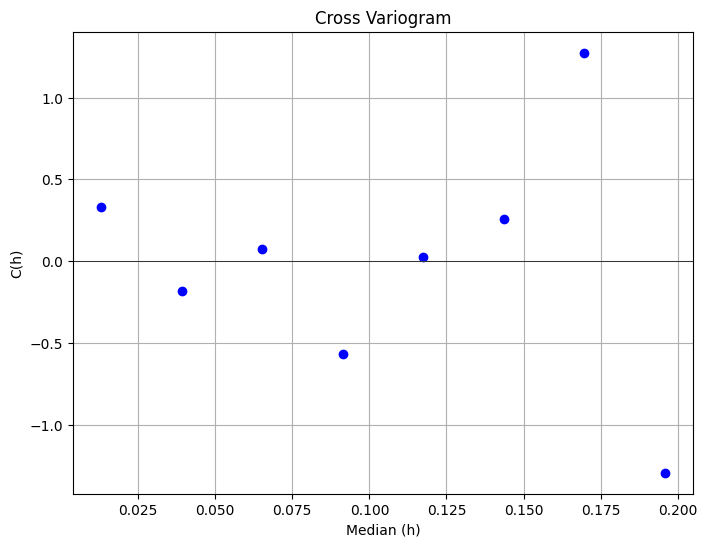

In [ ]:
import matplotlib.pyplot as plt

x = cross_variogram['Nilai Tengah']
y = cross_variogram['Ch']

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', marker='o')
plt.axhline(0, color='black', linewidth=0.5)  # Add x-axis line
plt.title('Cross Variogram')
plt.xlabel('Median (h)')
plt.ylabel('C(h)')
plt.grid(True)
plt.show()

## **Menentukan nilai P (nugget effect), Q (sill), dan r (range) pada Cross**

In [ ]:
P_cross = cross_variogram[cross_variogram['Ch']>0]['Ch'].min()
Q_cross = max(cross_variogram['Ch'])
loc_Q = cross_variogram['Ch'].idxmax()
r_cross = cross_variogram['Nilai Tengah'][loc_Q]
print("Nugget Effect (P) pada Cross Covarians U dan V :", P_cross)
print("Sill (Q) pada Cross Covarians U dan V :", Q_cross)
print("Range (r) pada Cross Covarians U dan V :", r_cross)

Nugget Effect (P) pada Cross Covarians U dan V : 0.028407072688167275
Sill (Q) pada Cross Covarians U dan V : 1.2744284063097036
Range (r) pada Cross Covarians U dan V : 0.1696618302781423


## **Auto-Covariance U (Variabel Primer)**

In [ ]:
import numpy as np
import pandas as pd

# Given data for u
u_data = data_uv.loc['u'].values

# Calculate mean of u
u_mean = np.mean(u_data)

# Initialize lists to store the results
loc_ui_list = []
loc_uj_list = []
ui_list = []
uj_list = []
val_list = []
hij_list = []
class_list = []

# Iterate over all unique pairs of elements in u_data
for i in range(len(u_data)):
    for j in range(i,len(u_data)):
        loc_ui_list.append(data_uv.loc['u'].index[i])
        loc_uj_list.append(data_uv.loc['u'].index[j])
        ui_list.append(u_data[i][0])
        uj_list.append(u_data[j][0])
        val_list.append((u_data[i][0] - u_mean) * (u_data[j][0] - u_mean))
        hij_list.append(mat_hij_u.loc[data_uv.loc['u'].index[i], data_uv.loc['u'].index[j]])

# Create a DataFrame from the lists
auto_cov_u = pd.DataFrame({
    'loc_ui': loc_ui_list,
    'loc_uj': loc_uj_list,
    'ui': ui_list,
    'uj': uj_list,
    'hij': hij_list,
    '(ui - u_mean)(uj - u_mean)': val_list
})

# Menambahkan kelas ke dataframe
auto_cov_u['kelas'] = auto_cov_u.apply(lambda row: find_class_with_location(row['hij'], bins, row['loc_ui'], row['loc_uj']), axis=1)

auto_cov_u

,loc_ui,loc_uj,ui,uj,hij,(ui - u_mean)(uj - u_mean),kelas
0,Jl. Kelapa Dua Srengseng Sawah,Jl. Kelapa Dua Srengseng Sawah,-1.350710,-1.350710,0.000000,1.824418,1
1,Jl. Kelapa Dua Srengseng Sawah,Komp Kopassus Cijantung,-1.350710,-0.770651,0.021526,1.040926,1
2,Jl. Kelapa Dua Srengseng Sawah,Kampung Gedong Intake PAM,-1.350710,1.143546,0.046294,-1.544599,2
3,Jl. Kelapa Dua Srengseng Sawah,Jl. Kalibata,-1.350710,1.201552,0.087996,-1.622949,4
4,Jl. Kelapa Dua Srengseng Sawah,Kampung Melayu Dalam,-1.350710,-0.306603,0.118156,0.414132,5
5,Jl. Kelapa Dua Srengseng Sawah,Sebelum Pintu Air Manggarai,-1.350710,-0.596633,0.132113,0.805878,6
6,Jl. Kelapa Dua Srengseng Sawah,Jl. Halimun,-1.350710,0.157445,0.138443,-0.212662,6
7,Jl. Kelapa Dua Srengseng Sawah,Jembatan Jalan Tambak,-1.350710,1.085540,0.142498,-1.466250,6
8,Jl. Kelapa Dua Srengseng Sawah,Jl. KH Mas Mansyur Karet Tengsin,-1.350710,-0.364609,0.144195,0.492481,6
9,Jl. Kelapa Dua Srengseng Sawah,Gudang PLN,-1.350710,-0.480621,0.147857,0.649179,6


## **Tabel Auto Covariance Variabel U**

In [ ]:
# Mengelompokkan dataframe berdasarkan kolom kelas dan menjumlahkan kolom '(ui - u_mean)(uj - u_mean)'
# serta menghitung jumlah pengamatan
auto_variogram_u = auto_cov_u.groupby('kelas').agg({'(ui - u_mean)(uj - u_mean)': 'sum', 'ui': 'size'}).reset_index()
auto_variogram_u.columns = ['kelas', 'Jumlah Covarians', 'N']
# Inner join berdasarkan kriteria kelas = index + 1
auto_variogram_u = pd.merge(auto_variogram_u, freq_dist, how='inner', left_on='kelas', right_on=freq_dist.index.values+1)
auto_variogram_u['Ch'] = auto_variogram_u['Jumlah Covarians']/auto_variogram_u['N']
# Cross-Variogram
auto_variogram_u

,kelas,Jumlah Covarians,N,Batas Bawah,Batas Atas,Nilai Tengah,Ch
0,1,13.671908,27,0.000000,0.026002,0.013001,0.506367
1,2,-4.984413,25,0.026102,0.052204,0.039153,-0.199377
2,3,1.576873,15,0.052204,0.078305,0.065255,0.105125
3,4,-6.023347,12,0.078305,0.104407,0.091356,-0.501946
4,5,0.472636,11,0.104407,0.130509,0.117458,0.042967
5,6,1.994095,8,0.130509,0.156611,0.143560,0.249262
6,7,5.022660,4,0.156611,0.182713,0.169662,1.255665
7,8,-4.730413,3,0.182713,0.208815,0.195764,-1.576804


## **Plot Auto Covariance Eksperimental U**

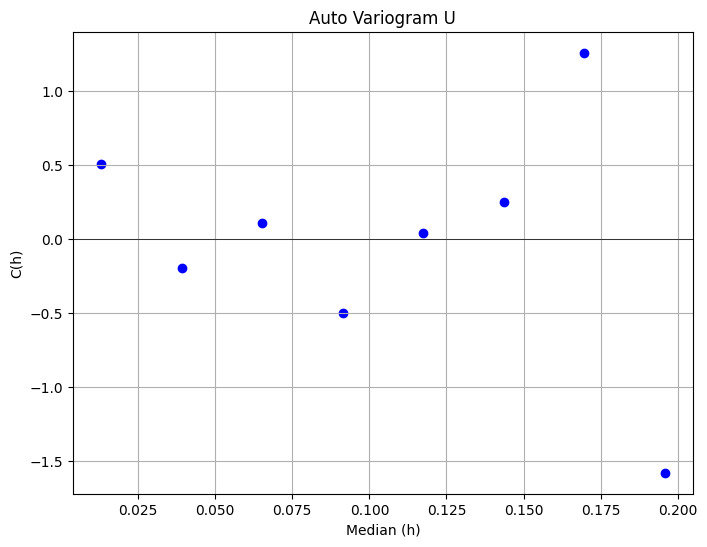

In [ ]:
import matplotlib.pyplot as plt

x = auto_variogram_u['Nilai Tengah']
y = auto_variogram_u['Ch']

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', marker='o')
plt.axhline(0, color='black', linewidth=0.5)  # Add x-axis line
plt.title('Auto Variogram U')
plt.xlabel('Median (h)')
plt.ylabel('C(h)')
plt.grid(True)
plt.show()

##**Menentukan nilai P (nugget effect), Q (sill), dan r (range) pada Auto Covariance Eksperimental U**


In [ ]:
P_auto_u = auto_variogram_u[auto_variogram_u['Ch']>0]['Ch'].min()
Q_auto_u = max(auto_variogram_u['Ch'])
loc_Q_u = auto_variogram_u['Ch'].idxmax()
r_auto_u = auto_variogram_u['Nilai Tengah'][loc_Q_u]
print("Nugget Effect (P) pada Auto Covarians U :", P_auto_u)
print("Sill (Q) pada Auto Covarians U :", Q_auto_u)
print("Range (r) pada Auto Covarians U :", r_auto_u)

Nugget Effect (P) pada Auto Covarians U : 0.04296692115136125
Sill (Q) pada Auto Covarians U : 1.255665041543638
Range (r) pada Auto Covarians U : 0.1696618302781423


## **Auto-Covariance V (Variabel Sekuner)**

In [ ]:
import numpy as np
import pandas as pd

# Given data for v
v_data = data_uv.loc['v'].values

# Calculate mean of u
v_mean = np.mean(v_data)

# Initialize lists to store the results
loc_vi_list = []
loc_vj_list = []
vi_list = []
vj_list = []
val_list = []
hij_list = []
class_list = []

# Iterate over all unique pairs of elements in v_data
for i in range(len(v_data)):
    for j in range(i,len(v_data)):
        loc_vi_list.append(data_uv.loc['v'].index[i])
        loc_vj_list.append(data_uv.loc['v'].index[j])
        vi_list.append(v_data[i][0])
        vj_list.append(v_data[j][0])
        val_list.append((v_data[i][0] - v_mean) * (v_data[j][0] - v_mean))
        hij_list.append(mat_hij_v.loc[data_uv.loc['v'].index[i], data_uv.loc['v'].index[j]])

# Create a DataFrame from the lists
auto_cov_v = pd.DataFrame({
    'loc_vi': loc_vi_list,
    'loc_vj': loc_vj_list,
    'vi': vi_list,
    'vj': vj_list,
    'hij': hij_list,
    '(vi - v_mean)(vj - v_mean)': val_list
})

# Menambahkan kelas ke dataframe
auto_cov_v['kelas'] = auto_cov_v.apply(lambda row: find_class_with_location(row['hij'], bins, row['loc_vi'], row['loc_vj']), axis=1)

auto_cov_v

,loc_vi,loc_vj,vi,vj,hij,(vi - v_mean)(vj - v_mean),kelas
0,Jl. Kelapa Dua Srengseng Sawah,Jl. Kelapa Dua Srengseng Sawah,-1.070921,-1.070921,0.000000,1.146872,1
1,Jl. Kelapa Dua Srengseng Sawah,Komp Kopassus Cijantung,-1.070921,-0.516051,0.021526,0.552650,1
2,Jl. Kelapa Dua Srengseng Sawah,Kampung Gedong Intake PAM,-1.070921,1.405222,0.046294,-1.504882,2
3,Jl. Kelapa Dua Srengseng Sawah,Jl. Kalibata,-1.070921,1.451461,0.087996,-1.554401,4
4,Jl. Kelapa Dua Srengseng Sawah,Kampung Melayu Dalam,-1.070921,-0.400118,0.118156,0.428494,5
5,Jl. Kelapa Dua Srengseng Sawah,Sebelum Pintu Air Manggarai,-1.070921,-0.677553,0.132113,0.725606,6
6,Jl. Kelapa Dua Srengseng Sawah,Jl. Halimun,-1.070921,0.039490,0.138443,-0.042291,6
7,Jl. Kelapa Dua Srengseng Sawah,Jembatan Jalan Tambak,-1.070921,0.965615,0.142498,-1.034097,6
8,Jl. Kelapa Dua Srengseng Sawah,Jl. KH Mas Mansyur Karet Tengsin,-1.070921,-0.469811,0.144195,0.503131,6
9,Jl. Kelapa Dua Srengseng Sawah,Gudang PLN,-1.070921,-0.562290,0.147857,0.602168,6


## **Tabel Auto Covariance Eksperimental V**

In [ ]:
# Mengelompokkan dataframe berdasarkan kolom kelas dan menjumlahkan kolom '(vi - v_mean)(vj - v_mean)'
# serta menghitung jumlah pengamatan
auto_variogram_v = auto_cov_v.groupby('kelas').agg({'(vi - v_mean)(vj - v_mean)': 'sum', 'vi': 'size'}).reset_index()
auto_variogram_v.columns = ['kelas', 'Jumlah Covarians', 'N']
# Inner join berdasarkan kriteria kelas = index + 1
auto_variogram_v = pd.merge(auto_variogram_v, freq_dist, how='inner', left_on='kelas', right_on=freq_dist.index.values+1)
auto_variogram_v['Ch'] = auto_variogram_v['Jumlah Covarians']/auto_variogram_v['N']
# Cross-Variogram
auto_variogram_v


,kelas,Jumlah Covarians,N,Batas Bawah,Batas Atas,Nilai Tengah,Ch
0,1,13.931691,27,0.000000,0.026002,0.013001,0.515989
1,2,-3.689212,25,0.026102,0.052204,0.039153,-0.147568
2,3,0.703452,15,0.052204,0.078305,0.065255,0.046897
3,4,-7.635670,12,0.078305,0.104407,0.091356,-0.636306
4,5,-0.137498,11,0.104407,0.130509,0.117458,-0.012500
5,6,1.927412,8,0.130509,0.156611,0.143560,0.240927
6,7,5.053791,4,0.156611,0.182713,0.169662,1.263448
7,8,-3.153966,3,0.182713,0.208815,0.195764,-1.051322


## **Plot Auto Covariance Eksperimental V**

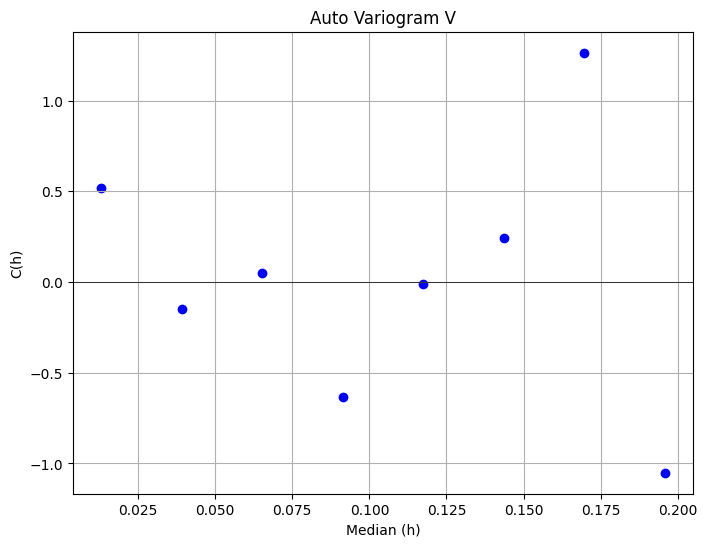

In [ ]:
import matplotlib.pyplot as plt

x = auto_variogram_v['Nilai Tengah']
y = auto_variogram_v['Ch']

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', marker='o')
plt.axhline(0, color='black', linewidth=0.5)  # Add x-axis line
plt.title('Auto Variogram V')
plt.xlabel('Median (h)')
plt.ylabel('C(h)')
plt.grid(True)
plt.show()


##**Menentukan nilai P (nugget effect), Q (sill), dan r (range) pada Auto Covariance Eksperimental V**

In [ ]:
P_auto_v = auto_variogram_v[auto_variogram_v['Ch']>0]['Ch'].min()
Q_auto_v = max(auto_variogram_v['Ch'])
loc_Q_v = auto_variogram_v['Ch'].idxmax()
r_auto_v = auto_variogram_v['Nilai Tengah'][loc_Q_v]
print("Nugget Effect (P) pada Auto Covarians V :", P_auto_v)
print("Sill (Q) pada Auto Covarians V :", Q_auto_v)
print("Range (r) pada Auto Covarians V :", r_auto_v)

Nugget Effect (P) pada Auto Covarians V : 0.046896805548013364
Sill (Q) pada Auto Covarians V : 1.263447753778585
Range (r) pada Auto Covarians V : 0.1696618302781423


# **SEMIVARIOGRAM TEORITIS**

## **Spherical**

In [ ]:
def ch_cross_sph(h,P_cross,Q_cross,r_cross):
    if h == 0:
        return P_cross + Q_cross
    elif 0 < h <= r_cross:
        return (P_cross + Q_cross)*(1-1.5*(h/r_cross)-0.5*(h/r_cross)**3)
    else:
        return 0

In [ ]:
def ch_auto_u_sph(h,P_auto_u,Q_auto_u,r_auto_u):
    if h == 0:
        return P_auto_u + Q_auto_u
    elif 0 < h <= r_auto_u:
        return (P_auto_u + Q_auto_u)*(1-1.5*(h/r_auto_u)-0.5*(h/r_auto_u)**3)
    else:
        return 0

In [ ]:
def ch_auto_v_sph(h,P_auto_v,Q_auto_v,r_auto_v):
    if h == 0:
        return P_auto_v + Q_auto_v
    elif 0 < h <= r_auto_v:
        return (P_auto_v + Q_auto_v)*(1-1.5*(h/r_auto_v)-0.5*(h/r_auto_v)**3)
    else:
        return 0

## **Matriks C(h) Teoritis Spherical**

In [ ]:
import pandas as pd

# Menampilkan semua kolom agar tidak terpotong
pd.set_option('display.max_columns', None)

# (Opsional) Menampilkan semua baris juga
pd.set_option('display.max_rows', None)

# (Opsional) Menampilkan semua lebar kolom
pd.set_option('display.max_colwidth', None)

# Create an empty DataFrame for mat_ch_sph
mat_ch_sph = pd.DataFrame(index=mat_hij.index, columns=mat_hij.columns)

# Iterate through the index of mat_ch_sph
for i in mat_ch_sph.index:
    for j in mat_ch_sph.columns:
        if i[0] == 'u' and j[0] == 'u':
            mat_ch_sph.loc[i, j] = ch_auto_u_sph(mat_hij.loc[i, j], P_auto_u, Q_auto_u, r_auto_u)
        elif i[0] == 'v' and j[0] == 'v':
            mat_ch_sph.loc[i, j] = ch_auto_v_sph(mat_hij.loc[i, j], P_auto_v, Q_auto_v, r_auto_v)
        else:
            mat_ch_sph.loc[i, j] = ch_cross_sph(mat_hij.loc[i, j], P_cross, Q_cross, r_cross)

# Tampilkan DataFrame
mat_ch_sph


u  \
                                   Jl. Kelapa Dua Srengseng Sawah   
u Jl. Kelapa Dua Srengseng Sawah                         1.298632   
  Komp Kopassus Cijantung                                1.050163   
  Kampung Gedong Intake PAM                              0.753919   
  Jl. Kalibata                                           0.197729   
  Kampung Melayu Dalam                                  -0.277283   
  Sebelum Pintu Air Manggarai                           -0.524788   
  Jl. Halimun                                           -0.643675   
  Jembatan Jalan Tambak                                 -0.722147   
  Jl. KH Mas Mansyur Karet Tengsin                      -0.755534   
  Gudang PLN                                            -0.828735   
  Jl. Kwitang Dalam Gunung Agung                        -1.103615   
  Jl. Inspeksi Banjir Istiqlal                                  0   
  Jl. Gajah Mada Tangki                                         0   
  Jl. Gunung Sahari Depan WTC                                   0   
v Jl. Kelapa Dua Srengseng Sawah                         1.302835   
  Komp Kopassus Cijantung                                1.053562   
  Kampung Gedong Intake PAM                              0.756359   
  Jl. Kalibata                                           0.198369   
  Kampung Melayu Dalam                                  -0.278181   
  Sebelum Pintu Air Manggarai                           -0.526486   
  Jl. Halimun                                           -0.645758   
  Jembatan Jalan Tambak                                 -0.724485   
  Jl. KH Mas Mansyur Karet Tengsin                       -0.75798   
  Gudang PLN                                            -0.831417   
  Jl. Kwitang Dalam Gunung Agung                        -1.107188   
  Jl. Inspeksi Banjir Istiqlal                                  0   
  Jl. Gajah Mada Tangki                                         0   
  Jl. Gunung Sahari Depan WTC                                   0   

                                                            \
                                   Komp Kopassus Cijantung   
u Jl. Kelapa Dua Srengseng Sawah                  1.050163   
  Komp Kopassus Cijantung                         1.298632   
  Kampung Gedong Intake PAM                       1.007323   
  Jl. Kalibata                                    0.492928   
  Kampung Melayu Dalam                            0.066965   
  Sebelum Pintu Air Manggarai                    -0.151057   
  Jl. Halimun                                     -0.26111   
  Jembatan Jalan Tambak                          -0.325868   
  Jl. KH Mas Mansyur Karet Tengsin               -0.372395   
  Gudang PLN                                     -0.441506   
  Jl. Kwitang Dalam Gunung Agung                 -0.666375   
  Jl. Inspeksi Banjir Istiqlal                   -0.895152   
  Jl. Gajah Mada Tangki                          -1.158269   
  Jl. Gunung Sahari Depan WTC                            0   
v Jl. Kelapa Dua Srengseng Sawah                  1.053562   
  Komp Kopassus Cijantung                         1.302835   
  Kampung Gedong Intake PAM                       1.010584   
  Jl. Kalibata                                    0.494523   
  Kampung Melayu Dalam                            0.067182   
  Sebelum Pintu Air Manggarai                    -0.151546   
  Jl. Halimun                                    -0.261956   
  Jembatan Jalan Tambak                          -0.326923   
  Jl. KH Mas Mansyur Karet Tengsin               -0.373601   
  Gudang PLN                                     -0.442935   
  Jl. Kwitang Dalam Gunung Agung                 -0.668532   
  Jl. Inspeksi Banjir Istiqlal                   -0.898049   
  Jl. Gajah Mada Tangki                          -1.162018   
  Jl. Gunung Sahari Depan WTC                            0   

                                                                           \
                                   Kampung Gedong Intak

## **Exponential**

In [ ]:
def ch_cross_exp(h,P_cross,Q_cross,r_cross):
    return (P_cross + Q_cross)*(1-np.exp(-h/r_cross))

In [ ]:
def ch_auto_u_exp(h,P_auto_u,Q_auto_u,r_auto_u):
    return (P_auto_u + Q_auto_u)*(1-np.exp(-h/r_auto_u))

In [ ]:
def ch_auto_v_exp(h,P_auto_v,Q_auto_v,r_auto_v):
    return (P_auto_v + Q_auto_v)*(1-np.exp(-h/r_auto_v))

## **Matriks C(h) Teoritis Eksponensial**

In [ ]:
# Menampilkan semua kolom agar tidak terpotong
pd.set_option('display.max_columns', None)

# (Opsional) Menampilkan semua baris juga
pd.set_option('display.max_rows', None)

# (Opsional) Menampilkan semua lebar kolom
pd.set_option('display.max_colwidth', None)

# Create an empty DataFrame for mat_ch_exp
mat_ch_exp = pd.DataFrame(index=mat_hij.index, columns=mat_hij.columns)

# Iterate through the index of mat_ch_exp
for i in mat_ch_exp.index:
    for j in mat_ch_exp.columns:
        if i[0] == 'u' and j[0] == 'u':
            mat_ch_exp.loc[i, j] = ch_auto_u_exp(mat_hij.loc[i, j], P_auto_u, Q_auto_u, r_auto_u)
        elif i[0] == 'v' and j[0] == 'v':
            mat_ch_exp.loc[i, j] = ch_auto_v_exp(mat_hij.loc[i, j], P_auto_v, Q_auto_v, r_auto_v)
        else:
            mat_ch_exp.loc[i, j] = ch_cross_exp(mat_hij.loc[i, j], P_cross, Q_cross, r_cross)
mat_ch_exp

u  \
                                   Jl. Kelapa Dua Srengseng Sawah   
u Jl. Kelapa Dua Srengseng Sawah                              0.0   
  Komp Kopassus Cijantung                                0.154738   
  Kampung Gedong Intake PAM                              0.310117   
  Jl. Kalibata                                           0.525529   
  Kampung Melayu Dalam                                    0.65144   
  Sebelum Pintu Air Manggarai                            0.702549   
  Jl. Halimun                                            0.724378   
  Jembatan Jalan Tambak                                   0.73794   
  Jl. KH Mas Mansyur Karet Tengsin                       0.743519   
  Gudang PLN                                             0.755374   
  Jl. Kwitang Dalam Gunung Agung                         0.795718   
  Jl. Inspeksi Banjir Istiqlal                           0.828253   
  Jl. Gajah Mada Tangki                                  0.860535   
  Jl. Gunung Sahari Depan WTC                            0.919343   
v Jl. Kelapa Dua Srengseng Sawah                              0.0   
  Komp Kopassus Cijantung                                0.155239   
  Kampung Gedong Intake PAM                              0.311121   
  Jl. Kalibata                                            0.52723   
  Kampung Melayu Dalam                                   0.653548   
  Sebelum Pintu Air Manggarai                            0.704823   
  Jl. Halimun                                            0.726723   
  Jembatan Jalan Tambak                                  0.740329   
  Jl. KH Mas Mansyur Karet Tengsin                       0.745926   
  Gudang PLN                                             0.757819   
  Jl. Kwitang Dalam Gunung Agung                         0.798293   
  Jl. Inspeksi Banjir Istiqlal                           0.830934   
  Jl. Gajah Mada Tangki                                   0.86332   
  Jl. Gunung Sahari Depan WTC                            0.922319   

                                                            \
                                   Komp Kopassus Cijantung   
u Jl. Kelapa Dua Srengseng Sawah                  0.154738   
  Komp Kopassus Cijantung                              0.0   
  Kampung Gedong Intake PAM                       0.179162   
  Jl. Kalibata                                     0.42231   
  Kampung Melayu Dalam                            0.564532   
  Sebelum Pintu Air Manggarai                     0.621958   
  Jl. Halimun                                     0.647802   
  Jembatan Jalan Tambak                           0.662135   
  Jl. KH Mas Mansyur Karet Tengsin                 0.67206   
  Gudang PLN                                      0.686257   
  Jl. Kwitang Dalam Gunung Agung                  0.728367   
  Jl. Inspeksi Banjir Istiqlal                    0.765702   
  Jl. Gajah Mada Tangki                           0.803036   
  Jl. Gunung Sahari Depan WTC                      0.86873   
v Jl. Kelapa Dua Srengseng Sawah                  0.155239   
  Komp Kopassus Cijantung                              0.0   
  Kampung Gedong Intake PAM                       0.179742   
  Jl. Kalibata                                    0.423677   
  Kampung Melayu Dalam                            0.566359   
  Sebelum Pintu Air Manggarai                     0.623971   
  Jl. Halimun                                     0.649899   
  Jembatan Jalan Tambak                           0.664279   
  Jl. KH Mas Mansyur Karet Tengsin                0.674236   
  Gudang PLN                                      0.688479   
  Jl. Kwitang Dalam Gunung Agung                  0.730725   
  Jl. Inspeksi Banjir Istiqlal                     0.76818   
  Jl. Gajah Mada Tangki                           0.805636   
  Jl. Gunung Sahari Depan WTC                     0.871542   

                                                                           \
                                   Kampung Gedong Intak

## **Gaussian**

In [ ]:
def ch_cross_gau(h,P_cross,Q_cross,r_cross):
    return (P_cross + Q_cross)*(1-np.exp(-(h/r_cross)**2))

In [ ]:
def ch_auto_u_gau(h,P_auto_u,Q_auto_u,r_auto_u):
    return (P_auto_u + Q_auto_u)*(1-np.exp(-(h/r_auto_u)**2))

In [ ]:
def ch_auto_v_gau(h,P_auto_v,Q_auto_v,r_auto_v):
    return (P_auto_v + Q_auto_v)*(1-np.exp(-(h/r_auto_v)**2))

## **Matriks C(h) Teoritis Gaussian**

In [ ]:
# Menampilkan semua kolom agar tidak terpotong
pd.set_option('display.max_columns', None)

# (Opsional) Menampilkan semua baris juga
pd.set_option('display.max_rows', None)

# (Opsional) Menampilkan semua lebar kolom
pd.set_option('display.max_colwidth', None)

# Create an empty DataFrame for mat_ch_gau
mat_ch_gau = pd.DataFrame(index=mat_hij.index, columns=mat_hij.columns)

# Iterate through the index of mat_ch_gau
for i in mat_ch_gau.index:
    for j in mat_ch_gau.columns:
        if i[0] == 'u' and j[0] == 'u':
            mat_ch_gau.loc[i, j] = ch_auto_u_gau(mat_hij.loc[i, j], P_auto_u, Q_auto_u, r_auto_u)
        elif i[0] == 'v' and j[0] == 'v':
            mat_ch_gau.loc[i, j] = ch_auto_v_gau(mat_hij.loc[i, j], P_auto_v, Q_auto_v, r_auto_v)
        else:
            mat_ch_gau.loc[i, j] = ch_cross_gau(mat_hij.loc[i, j], P_cross, Q_cross, r_cross)
mat_ch_gau

u  \
                                   Jl. Kelapa Dua Srengseng Sawah   
u Jl. Kelapa Dua Srengseng Sawah                              0.0   
  Komp Kopassus Cijantung                                0.020737   
  Kampung Gedong Intake PAM                              0.093177   
  Jl. Kalibata                                           0.306293   
  Kampung Melayu Dalam                                   0.499072   
  Sebelum Pintu Air Manggarai                             0.59044   
  Jl. Halimun                                            0.631346   
  Jembatan Jalan Tambak                                  0.657238   
  Jl. KH Mas Mansyur Karet Tengsin                       0.667986   
  Gudang PLN                                              0.69099   
  Jl. Kwitang Dalam Gunung Agung                         0.770611   
  Jl. Inspeksi Banjir Istiqlal                           0.835613   
  Jl. Gajah Mada Tangki                                  0.899892   
  Jl. Gunung Sahari Depan WTC                            1.013123   
v Jl. Kelapa Dua Srengseng Sawah                              0.0   
  Komp Kopassus Cijantung                                0.020804   
  Kampung Gedong Intake PAM                              0.093478   
  Jl. Kalibata                                           0.307285   
  Kampung Melayu Dalam                                   0.500688   
  Sebelum Pintu Air Manggarai                            0.592352   
  Jl. Halimun                                            0.633389   
  Jembatan Jalan Tambak                                  0.659366   
  Jl. KH Mas Mansyur Karet Tengsin                       0.670148   
  Gudang PLN                                             0.693227   
  Jl. Kwitang Dalam Gunung Agung                         0.773106   
  Jl. Inspeksi Banjir Istiqlal                           0.838318   
  Jl. Gajah Mada Tangki                                  0.902804   
  Jl. Gunung Sahari Depan WTC                            1.016402   

                                                            \
                                   Komp Kopassus Cijantung   
u Jl. Kelapa Dua Srengseng Sawah                  0.020737   
  Komp Kopassus Cijantung                              0.0   
  Kampung Gedong Intake PAM                       0.028308   
  Jl. Kalibata                                    0.186142   
  Kampung Melayu Dalam                            0.360692   
  Sebelum Pintu Air Manggarai                     0.449577   
  Jl. Halimun                                      0.49283   
  Jembatan Jalan Tambak                           0.517634   
  Jl. KH Mas Mansyur Karet Tengsin                0.535133   
  Gudang PLN                                      0.560605   
  Jl. Kwitang Dalam Gunung Agung                  0.638927   
  Jl. Inspeksi Banjir Istiqlal                    0.711199   
  Jl. Gajah Mada Tangki                           0.785205   
  Jl. Gunung Sahari Depan WTC                      0.91606   
v Jl. Kelapa Dua Srengseng Sawah                  0.020804   
  Komp Kopassus Cijantung                              0.0   
  Kampung Gedong Intake PAM                       0.028399   
  Jl. Kalibata                                    0.186744   
  Kampung Melayu Dalam                            0.361859   
  Sebelum Pintu Air Manggarai                     0.451032   
  Jl. Halimun                                     0.494426   
  Jembatan Jalan Tambak                            0.51931   
  Jl. KH Mas Mansyur Karet Tengsin                0.536865   
  Gudang PLN                                       0.56242   
  Jl. Kwitang Dalam Gunung Agung                  0.640995   
  Jl. Inspeksi Banjir Istiqlal                    0.713501   
  Jl. Gajah Mada Tangki                           0.787747   
  Jl. Gunung Sahari Depan WTC                     0.919025   

                                                                           \
                                   Kampung Gedong Intak

#**Function dari Analisis Co-Kriging for Predict banyak Lokasi**

## **Spherical**

In [ ]:
def calculate_z0_sph(locations, coordinates):
    results = []
    for loc, cor in zip(locations, coordinates):
        # Langkah 1
        df_0 = pd.DataFrame([cor], columns=['Latitude', 'Longitude'], index=[loc])
        df_u = pd.DataFrame(cor_u, columns=['Latitude', 'Longitude'], index=loc_u)
        df_v = pd.DataFrame(cor_v, columns=['Latitude', 'Longitude'], index=loc_v)
        distances_u = pd.DataFrame(distance.cdist(df_0.values, df_u.values), columns=loc_u, index=[loc])
        distances_v = pd.DataFrame(distance.cdist(df_0.values, df_v.values), columns=loc_v, index=[loc])
        dist_hi0 = pd.concat([distances_u, distances_v], keys=['u', 'v'], axis=1)
        mat_hi0 = np.transpose(dist_hi0)

        # Langkah 2
        n = len(df_u)
        m = len(df_v)
        M2 = np.concatenate((np.ones((n, 1)), np.zeros((n, 1))), axis=1)
        M3 = np.concatenate((np.zeros((m, 1)), np.ones((m, 1))), axis=1)
        M4 = np.zeros((2, 2))
        M5 = M2.T
        M6 = M3.T
        samping = np.concatenate((M2, M3), axis=0)
        top_row = np.concatenate((mat_ch_sph.values, samping), axis=1)
        bottom_row = np.concatenate((M6, M5, M4), axis=1)
        mat_C = np.concatenate((top_row, bottom_row), axis=0)
        mat_C = pd.DataFrame(mat_C)
        mat_ch0 = pd.DataFrame(index=mat_hi0.index, columns=mat_hi0.columns)

        for i in mat_ch0.index:
            for j in mat_ch0.columns:
                if i[0] == 'u':
                    mat_ch0.loc[i, j] = ch_auto_u_sph(mat_hi0.loc[i, j], P_auto_u, Q_auto_u, r_auto_u)
                else:
                    mat_ch0.loc[i, j] = ch_cross_sph(mat_hi0.loc[i, j], P_cross, Q_cross, r_cross)
        M7 = np.array([[1], [0]])
        mat_D = np.concatenate((mat_ch0.values, M7), axis=0)
        mat_D = pd.DataFrame(mat_D)
        mat_C = np.array(mat_C, dtype=float)
        C_inv = np.linalg.inv(mat_C)
        mat_w = np.dot(C_inv, mat_D)
        mat_w = pd.DataFrame(mat_w)
        mat_w = mat_w.rename(columns={0: 'Parameter'})

        # Langkah 3
        parm_w = mat_w.iloc[:-2]
        nil_uv = pd.DataFrame(data_uv.values)
        nil_uv = nil_uv.rename(columns={0: 'Nilai U dan V'})
        pers_z0 = pd.concat([parm_w, nil_uv], axis=1, join='inner')
        z0 = sum(pers_z0['Parameter']*pers_z0['Nilai U dan V'])
        results.append((loc, z0))

    results_df = pd.DataFrame(results, columns=['Location', 'Nilai z0 (scaled)'])
    return results_df

## **Exponential**

In [ ]:
def calculate_z0_exp(locations, coordinates):
    results = []
    for loc, cor in zip(locations, coordinates):
        # Langkah 1
        df_0 = pd.DataFrame([cor], columns=['Latitude', 'Longitude'], index=[loc])
        df_u = pd.DataFrame(cor_u, columns=['Latitude', 'Longitude'], index=loc_u)
        df_v = pd.DataFrame(cor_v, columns=['Latitude', 'Longitude'], index=loc_v)
        distances_u = pd.DataFrame(distance.cdist(df_0.values, df_u.values), columns=loc_u, index=[loc])
        distances_v = pd.DataFrame(distance.cdist(df_0.values, df_v.values), columns=loc_v, index=[loc])
        dist_hi0 = pd.concat([distances_u, distances_v], keys=['u', 'v'], axis=1)
        mat_hi0 = np.transpose(dist_hi0)

        # Langkah 2
        n = len(df_u)
        m = len(df_v)
        M2 = np.concatenate((np.ones((n, 1)), np.zeros((n, 1))), axis=1)
        M3 = np.concatenate((np.zeros((m, 1)), np.ones((m, 1))), axis=1)
        M4 = np.zeros((2, 2))
        M5 = M2.T
        M6 = M3.T
        samping = np.concatenate((M2, M3), axis=0)
        top_row = np.concatenate((mat_ch_exp.values, samping), axis=1)
        bottom_row = np.concatenate((M6, M5, M4), axis=1)
        mat_C = np.concatenate((top_row, bottom_row), axis=0)
        mat_C = pd.DataFrame(mat_C)
        mat_ch0 = pd.DataFrame(index=mat_hi0.index, columns=mat_hi0.columns)

        for i in mat_ch0.index:
            for j in mat_ch0.columns:
                if i[0] == 'u':
                    mat_ch0.loc[i, j] = ch_auto_u_exp(mat_hi0.loc[i, j], P_auto_u, Q_auto_u, r_auto_u)
                else:
                    mat_ch0.loc[i, j] = ch_cross_exp(mat_hi0.loc[i, j], P_cross, Q_cross, r_cross)
        M7 = np.array([[1], [0]])
        mat_D = np.concatenate((mat_ch0.values, M7), axis=0)
        mat_D = pd.DataFrame(mat_D)
        mat_C = np.array(mat_C, dtype=float)
        C_inv = np.linalg.inv(mat_C)
        mat_w = np.dot(C_inv, mat_D)
        mat_w = pd.DataFrame(mat_w)
        mat_w = mat_w.rename(columns={0: 'Parameter'})

        # Langkah 3
        parm_w = mat_w.iloc[:-2]
        nil_uv = pd.DataFrame(data_uv.values)
        nil_uv = nil_uv.rename(columns={0: 'Nilai U dan V'})
        pers_z0 = pd.concat([parm_w, nil_uv], axis=1, join='inner')
        z0 = sum(pers_z0['Parameter']*pers_z0['Nilai U dan V'])
        results.append((loc, z0))

    results_df = pd.DataFrame(results, columns=['Location', 'Nilai z0 (scaled)'])
    return results_df

## **Gaussian**

In [ ]:
def calculate_z0_gau(locations, coordinates):
    results = []
    for loc, cor in zip(locations, coordinates):
        # Langkah 1
        df_0 = pd.DataFrame([cor], columns=['Latitude', 'Longitude'], index=[loc])
        df_u = pd.DataFrame(cor_u, columns=['Latitude', 'Longitude'], index=loc_u)
        df_v = pd.DataFrame(cor_v, columns=['Latitude', 'Longitude'], index=loc_v)
        distances_u = pd.DataFrame(distance.cdist(df_0.values, df_u.values), columns=loc_u, index=[loc])
        distances_v = pd.DataFrame(distance.cdist(df_0.values, df_v.values), columns=loc_v, index=[loc])
        dist_hi0 = pd.concat([distances_u, distances_v], keys=['u', 'v'], axis=1)
        mat_hi0 = np.transpose(dist_hi0)

        # Langkah 2
        n = len(df_u)
        m = len(df_v)
        M2 = np.concatenate((np.ones((n, 1)), np.zeros((n, 1))), axis=1)
        M3 = np.concatenate((np.zeros((m, 1)), np.ones((m, 1))), axis=1)
        M4 = np.zeros((2, 2))
        M5 = M2.T
        M6 = M3.T
        samping = np.concatenate((M2, M3), axis=0)
        top_row = np.concatenate((mat_ch_gau.values, samping), axis=1)
        bottom_row = np.concatenate((M6, M5, M4), axis=1)
        mat_C = np.concatenate((top_row, bottom_row), axis=0)
        mat_C = pd.DataFrame(mat_C)
        mat_ch0 = pd.DataFrame(index=mat_hi0.index, columns=mat_hi0.columns)

        for i in mat_ch0.index:
            for j in mat_ch0.columns:
                if i[0] == 'u':
                    mat_ch0.loc[i, j] = ch_auto_u_gau(mat_hi0.loc[i, j], P_auto_u, Q_auto_u, r_auto_u)
                else:
                    mat_ch0.loc[i, j] = ch_cross_gau(mat_hi0.loc[i, j], P_cross, Q_cross, r_cross)
        M7 = np.array([[1], [0]])
        mat_D = np.concatenate((mat_ch0.values, M7), axis=0)
        mat_D = pd.DataFrame(mat_D)
        mat_C = np.array(mat_C, dtype=float)
        C_inv = np.linalg.inv(mat_C)
        mat_w = np.dot(C_inv, mat_D)
        mat_w = pd.DataFrame(mat_w)
        mat_w = mat_w.rename(columns={0: 'Parameter'})

        # Langkah 3
        parm_w = mat_w.iloc[:-2]
        nil_uv = pd.DataFrame(data_uv.values)
        nil_uv = nil_uv.rename(columns={0: 'Nilai U dan V'})
        pers_z0 = pd.concat([parm_w, nil_uv], axis=1, join='inner')
        z0 = sum(pers_z0['Parameter']*pers_z0['Nilai U dan V'])
        results.append((loc, z0))

    results_df = pd.DataFrame(results, columns=['Location', 'Nilai z0 (scaled)'])
    return results_df

## **Invers Transform Data**

In [ ]:
# Mengembalikan data_u ke bentuk aslinya
data_u_sb = scaler_u.inverse_transform(data_u)

# Mengembalikan data_v ke bentuk aslinya
data_v_sb = scaler_v.inverse_transform(data_v)

# **PREDIKSI DATA TRAINING**

## **Spherical**

In [ ]:
from scipy.spatial import distance

# Memanggil fungsi dengan input yang diberikan
train_result_sph = calculate_z0_sph(loc_u, cor_u)
train_result_sph['Data Asli'] = data_u_sb
z0_scaled = train_result_sph['Nilai z0 (scaled)'].values.reshape(-1,1)
train_result_sph['Nilai z0 (Asli)'] = scaler_u.inverse_transform(z0_scaled)
# Menampilkan DataFrame hasil
train_result_sph

,Location,Nilai z0 (scaled),Data Asli,Nilai z0 (Asli)
0,Jl. Kelapa Dua Srengseng Sawah,-1.288782,4.8,4.906762
1,Komp Kopassus Cijantung,-0.708722,5.8,5.906762
2,Kampung Gedong Intake PAM,1.205475,9.1,9.206762
3,Jl. Kalibata,1.263481,9.2,9.306762
4,Kampung Melayu Dalam,-0.244674,6.6,6.706762
5,Sebelum Pintu Air Manggarai,-0.534704,6.1,6.206762
6,Jl. Halimun,0.219373,7.4,7.506762
7,Jembatan Jalan Tambak,1.147469,9.0,9.106762
8,Jl. KH Mas Mansyur Karet Tengsin,-0.302680,6.5,6.606762
9,Gudang PLN,-0.418692,6.3,6.406762


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
mse_train_sph = mean_squared_error(train_result_sph['Data Asli'],train_result_sph['Nilai z0 (Asli)'])
mape_train_sph = mean_absolute_percentage_error(train_result_sph['Data Asli'],train_result_sph['Nilai z0 (Asli)'])*100
print("Nilai MSE Data Training : ", mse_train_sph)
print("Nilai MAPE Data Training : ", mape_train_sph)

Nilai MSE Data Training :  0.011398225592991607
Nilai MAPE Data Training :  1.5833887070876653


## **Exponential**

In [ ]:
# Memanggil fungsi dengan input yang diberikan
train_result_exp = calculate_z0_exp(loc_u, cor_u)
train_result_exp['Data Asli'] = data_u_sb
z0_scaled = train_result_exp['Nilai z0 (scaled)'].values.reshape(-1,1)
train_result_exp['Nilai z0 (Asli)'] = scaler_u.inverse_transform(z0_scaled)
# Menampilkan DataFrame hasil
train_result_exp

,Location,Nilai z0 (scaled),Data Asli,Nilai z0 (Asli)
0,Jl. Kelapa Dua Srengseng Sawah,-1.297980,4.8,4.890905
1,Komp Kopassus Cijantung,-0.717920,5.8,5.890905
2,Kampung Gedong Intake PAM,1.196276,9.1,9.190905
3,Jl. Kalibata,1.254282,9.2,9.290905
4,Kampung Melayu Dalam,-0.253873,6.6,6.690905
5,Sebelum Pintu Air Manggarai,-0.543902,6.1,6.190905
6,Jl. Halimun,0.210175,7.4,7.490905
7,Jembatan Jalan Tambak,1.138271,9.0,9.090905
8,Jl. KH Mas Mansyur Karet Tengsin,-0.311878,6.5,6.590905
9,Gudang PLN,-0.427890,6.3,6.390905


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
mse_train_exp = mean_squared_error(train_result_exp['Data Asli'],train_result_exp['Nilai z0 (Asli)'])
mape_train_exp = mean_absolute_percentage_error(train_result_exp['Data Asli'],train_result_exp['Nilai z0 (Asli)'])*100
print("Nilai MSE Data Training : ", mse_train_exp)
print("Nilai MAPE Data Training : ", mape_train_exp)

Nilai MSE Data Training :  0.008263750823095054
Nilai MAPE Data Training :  1.3482099431308092


## **Gaussian**

In [ ]:
# Memanggil fungsi dengan input yang diberikan
train_result_gau = calculate_z0_gau(loc_u, cor_u)
train_result_gau['Data Asli'] = data_u_sb
z0_scaled = train_result_gau['Nilai z0 (scaled)'].values.reshape(-1,1)
train_result_gau['Nilai z0 (Asli)'] = scaler_u.inverse_transform(z0_scaled)
# Menampilkan DataFrame hasil
train_result_gau

,Location,Nilai z0 (scaled),Data Asli,Nilai z0 (Asli)
0,Jl. Kelapa Dua Srengseng Sawah,-7.423629,4.8,-5.669474
1,Komp Kopassus Cijantung,-6.865825,5.8,-4.707842
2,Kampung Gedong Intake PAM,-4.972518,9.1,-1.443854
3,Jl. Kalibata,-4.930057,9.2,-1.370654
4,Kampung Melayu Dalam,-6.430511,6.6,-3.957378
5,Sebelum Pintu Air Manggarai,-6.709676,6.1,-4.438646
6,Jl. Halimun,-5.942118,7.4,-3.115407
7,Jembatan Jalan Tambak,-5.016389,9.0,-1.519486
8,Jl. KH Mas Mansyur Karet Tengsin,-6.450667,6.5,-3.992125
9,Gudang PLN,-6.560766,6.3,-4.181932


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
mse_train_gau = mean_squared_error(train_result_gau['Data Asli'],train_result_gau['Nilai z0 (Asli)'])
mape_train_gau = mean_absolute_percentage_error(train_result_gau['Data Asli'],train_result_gau['Nilai z0 (Asli)'])*100
print("Nilai MSE Data Training : ", mse_train_gau)
print("Nilai MAPE Data Training : ", mape_train_gau)

Nilai MSE Data Training :  110.11623339361886
Nilai MAPE Data Training :  155.61715391247546


#**Perbandingan Performansi Model Semivariogram (Training)**

In [ ]:
compare_train = pd.DataFrame({
    'Model Semivariogram': ["Spherical","Exponential","Gaussian"],
    'MSE Train': [mse_train_sph, mse_train_exp, mse_train_gau],
    'MAPE Train': [mape_train_sph, mape_train_exp, mape_train_gau],
})
compare_train

,Model Semivariogram,MSE Train,MAPE Train
0,Spherical,0.011398,1.583389
1,Exponential,0.008264,1.348210
2,Gaussian,110.116233,155.617154


# **PREDIKSI DATA TESTING**

In [ ]:
import pandas as pd
df_test = pd.read_excel('/content/data testing ads.xlsx')
df_test

,alamat,latitude,longitude,bod,cod
0,Jl. Pakin,-6.127554,106.809431,5.2,38.33
1,Jl. Raya Pluit Penjaringan,-6.125122,106.802086,6.8,52.49
2,Jembatan Pantai Indah Kapuk,-6.116667,106.773469,4.6,33.84
3,Outlet Pompa Danau Pluit,-6.109725,106.797183,6.2,47.31


In [ ]:
import numpy as np
import pandas as pd

latitude = df_test['latitude'].values
longitude = df_test['longitude'].values


# Create the cor_u and cor_v array
cor_test = np.column_stack((latitude, longitude))

loc_test = np.array(df_test['alamat'])
data_test = np.array(df_test['bod'])

## **Spherical**

In [ ]:
test_result_sph = calculate_z0_sph(loc_test, cor_test)
z0_scaled = test_result_sph['Nilai z0 (scaled)'].values.reshape(-1,1)
test_result_sph['Nilai z0 (Asli)'] = scaler_u.inverse_transform(z0_scaled)
test_result_sph['Data Asli'] = data_test
# Menampilkan DataFrame hasil
test_result_sph

,Location,Nilai z0 (scaled),Nilai z0 (Asli),Data Asli
0,Jl. Pakin,-0.679305,5.957476,5.2
1,Jl. Raya Pluit Penjaringan,-0.674146,5.966370,6.8
2,Jembatan Pantai Indah Kapuk,-0.818427,5.717635,4.6
3,Outlet Pompa Danau Pluit,-1.008240,5.390404,6.2


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
mse_test_sph = mean_squared_error(test_result_sph['Data Asli'],test_result_sph['Nilai z0 (Asli)'])
mape_test_sph = mean_absolute_percentage_error(test_result_sph['Data Asli'],test_result_sph['Nilai z0 (Asli)'])*100
print("Nilai MSE Data Testing : ", mse_test_sph)
print("Nilai MAPE Data Testing : ", mape_test_sph)

Nilai MSE Data Testing :  0.7933155683820001
Nilai MAPE Data Testing :  16.045130768978755


## **Exponential**

In [ ]:
test_result_exp = calculate_z0_exp(loc_test, cor_test)
z0_scaled = test_result_exp['Nilai z0 (scaled)'].values.reshape(-1,1)
test_result_exp['Nilai z0 (Asli)'] = scaler_u.inverse_transform(z0_scaled)
test_result_exp['Data Asli'] = data_test
# Menampilkan DataFrame hasil
test_result_exp

,Location,Nilai z0 (scaled),Nilai z0 (Asli),Data Asli
0,Jl. Pakin,1.578888,9.850513,5.2
1,Jl. Raya Pluit Penjaringan,1.452568,9.632742,6.8
2,Jembatan Pantai Indah Kapuk,1.115102,9.050964,4.6
3,Outlet Pompa Danau Pluit,1.504483,9.722241,6.2


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
mse_test_exp = mean_squared_error(test_result_exp['Data Asli'],test_result_exp['Nilai z0 (Asli)'])
mape_test_exp = mean_absolute_percentage_error(test_result_exp['Data Asli'],test_result_exp['Nilai z0 (Asli)'])*100
print("Nilai MSE Data Testing : ", mse_test_exp)
print("Nilai MAPE Data Testing : ", mape_test_exp)

Nilai MSE Data Testing :  15.467240870150793
Nilai MAPE Data Testing :  71.16533631472983


## **Gaussian**

In [ ]:
test_result_gau = calculate_z0_gau(loc_test, cor_test)
z0_scaled = test_result_gau['Nilai z0 (scaled)'].values.reshape(-1,1)
test_result_gau['Nilai z0 (Asli)'] = scaler_u.inverse_transform(z0_scaled)
test_result_gau['Data Asli'] = data_test
# Menampilkan DataFrame hasil
test_result_gau

,Location,Nilai z0 (scaled),Nilai z0 (Asli),Data Asli
0,Jl. Pakin,30.668112,59.999194,5.2
1,Jl. Raya Pluit Penjaringan,48.323061,90.435634,6.8
2,Jembatan Pantai Indah Kapuk,191.270403,336.871247,4.6
3,Outlet Pompa Danau Pluit,53.948062,100.132915,6.2


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
mse_test_gau = mean_squared_error(test_result_gau['Data Asli'],test_result_gau['Nilai z0 (Asli)'])
mape_test_gau = mean_absolute_percentage_error(test_result_gau['Data Asli'],test_result_gau['Nilai z0 (Asli)'])*100
print("Nilai MSE Data Testing : ", mse_test_gau)
print("Nilai MAPE Data Testing : ", mape_test_gau)

Nilai MSE Data Testing :  32306.361214691242
Nilai MAPE Data Testing :  2755.525358804785


# **PERBANDINGAN PERFORMANSI MODEL SEMIVARIOGRAM  (TESTING)**

In [ ]:
compare_test = pd.DataFrame({
    'Model Semivariogram': ["Spherical","Exponential","Gaussian"],
    'MSE Test': [mse_test_sph, mse_test_exp, mse_test_gau],
    'MAPE Test': [mape_test_sph, mape_test_exp, mape_test_gau],
})
compare_test

,Model Semivariogram,MSE Test,MAPE Test
0,Spherical,0.793316,16.045131
1,Exponential,15.467241,71.165336
2,Gaussian,32306.361215,2755.525359
